In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.metrics.pairwise import haversine_distances
from enum import Enum
from tqdm import tqdm

from data_visualisation import *

# Data Handling and Preprocessing

In [2]:
def import_data(data : str) -> pd.DataFrame:
    if not os.path.exists(data):
        print("Error: file does not exist.")
        return None
    df = pd.read_csv(data)
    return df

In [3]:
def preprocess_data (df: pd.DataFrame, min_population : float =1e5) -> pd.DataFrame:
    df = df.dropna()
    df = df[df['country'] == 'India']
    df = df[df['population'] >= min_population]
    df = df[df['lng'].between(65, 100) & df['lat'].between(5, 40)]
    df = df.drop_duplicates(subset=['city'])
    df = df[['city', 'population', 'country', 'lat', 'lng']].copy()
    df = df.reset_index(drop=True)
    df.insert(0, 'city_id', range(len(df)))
    
    return df

In [4]:
data_path = "data/indiacities.csv"

df = import_data(data_path)
df = preprocess_data(df, 1e5)
df.to_csv("data/cities_data.csv", index = False)

# Cost Calculations

### Constants

In [5]:
class TransportMode(Enum):
    ROAD = "road"
    RAIL = "rail"
    AIR = "air"
    
## Cost of travel when transporting freight by different modes (INR/tonne-km)
TRAVEL_COSTS_TONNE_KM = {
    TransportMode.ROAD: 3.6,
    TransportMode.RAIL: 1.6,
    TransportMode.AIR: 18,
}

## CO2 emissions when transporting freight by different modes (gm CO2/tonne-km)
CO2_EMISSIONS_TONNE_KM = {
    TransportMode.ROAD: 101,
    TransportMode.RAIL: 11.5,
    TransportMode.AIR: 610,
}

TRAVEL_SPEEDS = {
    TransportMode.ROAD: 30,
    TransportMode.RAIL: 35,
    TransportMode.AIR: 450,
}

In [6]:
COST_OF_CARBON_KG = 4.42    # Median carbon shadow price in major corporations $49/tonne = INR 4.42/kg CO2
CONSUMPTION_RATE = 2.78   # Average parcels per person
AVG_WEIGHT_PER_UNIT_KG = 1.5 # Typical Amazon parcel avg weight
TIME_VALUE_KG_HOUR = 2.0
AOV_INDIA = 9600.0
CARRYING_RATE = 0.20
CARRYING_COST_PARCEL_HOUR = AOV_INDIA*CARRYING_RATE/8760
TIME_VALUE_KG_HOUR = CARRYING_COST_PARCEL_HOUR*AVG_WEIGHT_PER_UNIT_KG
SHIPMENT_WEIGHT_PER_PERSON = CONSUMPTION_RATE*AVG_WEIGHT_PER_UNIT_KG
WAREHOUSE_LAND_AREA = 2.5e5
LAND_RENT_SQFT_YEAR = 24*12
OPEX_RATIO = 0.5
WAREHOUSE_COST = WAREHOUSE_LAND_AREA*LAND_RENT_SQFT_YEAR*(1+OPEX_RATIO)

### Cost Functions

In [7]:
def get_distance_matrix(df: pd.DataFrame) -> pd.DataFrame:

    lat = df["lat"].to_numpy()
    lng = df["lng"].to_numpy()
    cities = df["city"].to_numpy()
    
    coords = np.column_stack([np.radians(lat), np.radians(lng)])
    d_mat = haversine_distances(coords)
    
    # Convert radians to km (Earth radius = 6371 km)
    d_mat = d_mat * 6371

    return pd.DataFrame(d_mat, index=cities, columns=cities)

In [8]:
def calc_fuel_cost(distance_km: float, 
                   mode: TransportMode, 
                   weight_kg: float, 
                   travel_costs_tonne_km: dict = TRAVEL_COSTS_TONNE_KM) -> float:
    
    tonnes = weight_kg/1000
    linear_cost = travel_costs_tonne_km[mode]
    if mode == TransportMode.AIR:
        a_takeoff = 6500.0
        k_takeoff = 0.008
        
        return tonnes * (a_takeoff * (1 - np.exp(-k_takeoff * distance_km)) + linear_cost * distance_km)
    else:
        return linear_cost * tonnes * distance_km

In [9]:
def calc_carbon_cost(distance_km: float, 
                     mode: TransportMode, 
                     weight_kg: float, 
                     emissions_tonne_km: dict = CO2_EMISSIONS_TONNE_KM, 
                     cost_of_carbon_kg: float = COST_OF_CARBON_KG) -> float:
    
    tonnes = weight_kg / 1000.0
    emission_rate = emissions_tonne_km[mode]
    total_emissions_kg = (emission_rate * tonnes * distance_km) / 1000.0
    return total_emissions_kg * cost_of_carbon_kg

In [10]:
def calc_time_penalty(distance_km: float, 
                      mode: TransportMode, 
                      weight_kg: float, 
                      time_value_kg_hour: float = TIME_VALUE_KG_HOUR) -> float:
    
    # Avg block speeds
    speeds = {
        TransportMode.AIR: 532.0,
        TransportMode.RAIL: 25.0,
        TransportMode.ROAD: 30.0,
    }
    
    travel_hours = distance_km / speeds[mode]
    
    # 1. Pipeline Inventory Cost (Capital tied up in transit)
    holding_cost = travel_hours * time_value_kg_hour * weight_kg
    
    # 2. Service Penalty (Modeling lost sales/customer dissatisfaction)
    # service_penalty = 0.0
    # if travel_hours > 48:
    #     service_penalty = (travel_hours-48)*(time_value_kg_hour*100)*weight_kg
        
    return holding_cost 
    # + service_penalty

In [11]:
def get_transport_mode_cost(distance_km: float, 
                            mode: TransportMode, 
                            shipment_weight_kg: float, 
                            cost_weights: dict) -> tuple[float, dict]:
    
    fuel = calc_fuel_cost(distance_km, mode, shipment_weight_kg)
    carbon = calc_carbon_cost(distance_km, mode, shipment_weight_kg)
    time = calc_time_penalty(distance_km, mode, shipment_weight_kg)
    
    cost_components = {
        "fuel": fuel,
        "carbon": carbon,
        "time": time,
        "mode": mode,
    }
    
    # Normalisation
    cost_weights = {k: v/sum(cost_weights.values()) for k,v in cost_weights.items()}
    
    weighted_cost = fuel*cost_weights["fuel"] + carbon*cost_weights["carbon"]+time*cost_weights["time"]
    
    return weighted_cost, cost_components

In [12]:
def get_transport_cost(source: str, 
                       dest: str, 
                       distance_matrix: pd.DataFrame,
                       df: pd.DataFrame,
                       air_df: pd.DataFrame, 
                       rail_df: pd.DataFrame, 
                       cost_weights: dict) -> tuple[float, dict]:

    dest_population = df.loc[df['city'] == dest]['population'].iloc[0]
    shipment_weight_kg = dest_population * SHIPMENT_WEIGHT_PER_PERSON

    
    distance = distance_matrix[source][dest]
    rail_cost = float('inf')
    air_cost = float('inf')
    road_cost = float('inf')
    components = {
        "fuel": float('inf'),
        "carbon": float('inf'),
        "time": float('inf'),
        "mode": 'not known',
    }
    if not (source == "Port Blair" or dest == "Port Blair"):
        road_cost, components = get_transport_mode_cost(distance, TransportMode.ROAD, shipment_weight_kg, cost_weights)

    optimal_cost = road_cost
        
    if source in air_df["city"].values and dest in air_df["city"].values:
        air_cost, comp = get_transport_mode_cost(distance, TransportMode.AIR, shipment_weight_kg, cost_weights)
        if air_cost < optimal_cost:
            optimal_cost = air_cost
            components = comp
    if source in rail_df["city"].values and dest in rail_df["city"].values:
        rail_cost, comp = get_transport_mode_cost(distance, TransportMode.RAIL, shipment_weight_kg, cost_weights)
        if rail_cost < optimal_cost:
            optimal_cost = rail_cost
            components = comp

    return optimal_cost, components

In [13]:
def get_direct_transport_cost_matrix(df: pd.DataFrame,
                         air_df: pd.DataFrame,
                         rail_df: pd.DataFrame,
                         distance_matrix: pd.DataFrame,
                         cost_weights: dict) -> pd.DataFrame:
    cities = df["city"].values
    n = len(cities)
    cost_matrix = np.zeros((n,n))
    city_to_idx = {city: idx for idx, city in enumerate(cities)}

    data = {}
    
    for source in tqdm(cities, desc="Building transport cost matrix"):
        row_data = {}
        for dest in cities:
            if source == dest:
                row_data[dest] = (0, {'fuel': 0, 'carbon': 0, 'time': 0, 'mode': 'no transport'})
            else:
                optimal_cost, components = get_transport_cost(
                    source, dest, distance_matrix, df, air_df, rail_df, cost_weights
                )
                row_data[dest] = (optimal_cost, components)
        data[source] = row_data
    
    # Convert to pandas DataFrame with city names as index and columns
    return pd.DataFrame(data).T

In [14]:
def floyd_warshall(transport_cost_matrix: pd.DataFrame,
                   cities: np.ndarray) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    dist_dict = {}
    components_dict = {}
    next_node_dict = {}

    for source in cities:
        dist_dict[source] = {}
        components_dict[source] = {}
        next_node_dict[source] = {}

        for dest in cities:
            next_node_dict[source][dest] = None
            if source == dest:
                dist_dict[source][dest] = 0
                components_dict[source][dest] = {'fuel': 0, 'carbon': 0, 'time': 0, 'mode': 'no transport'}
            elif source in transport_cost_matrix.index and dest in transport_cost_matrix.columns:
                cost, components = transport_cost_matrix[source][dest]
                dist_dict[source][dest] = cost
                components_dict[source][dest] = components.copy()
            else:
                dist_dict[source][dest] = float('inf')
                components_dict[source][dest] = {'fuel': float('inf'), 'carbon': float('inf'), 'time': float('inf')}

    for k in tqdm(cities, desc="Running Floyd Warshall algorithm"):
        for i in cities:
            for j in cities:
                if dist_dict[i][k]+dist_dict[k][j] < dist_dict[i][j]:
                    dist_dict[i][j] = dist_dict[i][k] + dist_dict[k][j]
                    next_node_dict[i][j] = k
                    components_dict[i][j] = {
                        'fuel': components_dict[i][k]['fuel'] + components_dict[k][j]['fuel'],
                        'carbon': components_dict[i][k]['carbon'] + components_dict[k][j]['carbon'],
                        'time': components_dict[i][k]['time'] + components_dict[k][j]['time'],
                        'mode': 'mixed',
                    }

    dist_df = pd.DataFrame(dist_dict).T
    components_df = pd.DataFrame(components_dict).T
    next_node_df = pd.DataFrame(next_node_dict).T

    return dist_df, components_df, next_node_df

In [32]:
def analyse_network(df: pd.DataFrame,
                    air_df:pd.DataFrame,
                    rail_df: pd.DataFrame,
                    weights: dict) -> tuple:
    print("Step 1/3: Calculating physical distance matrix...")
    dist_matrix = get_distance_matrix(df)

    print("Step 2/3: Building direct transport cost matrix...")
    direct_cost_matrix = get_direct_transport_cost_matrix(
        df=df,
        air_df=air_df,
        rail_df=rail_df,
        distance_matrix=dist_matrix,
        cost_weights=weights
    )

    print("Step 3/3: Running Floyd-Warshall algorithm...")
    cities = df["city"].values
    return floyd_warshall(transport_cost_matrix=direct_cost_matrix, cities=cities)

In [96]:
def assign_fcs(df: pd.DataFrame,
               fc_df: pd.DataFrame,
               transport_costs: pd.DataFrame,
               cost_components: pd.DataFrame) -> pd.DataFrame:
    all_cities = df['city'].values
    fc_cities = fc_df['city'].values

    cost_matrix = transport_costs.loc[fc_cities, all_cities].values
     # Find index of minimum cost FC for each city (argmin across rows/FCs)
    best_fc_indices = np.argmin(cost_matrix, axis=0)
    best_costs = np.min(cost_matrix, axis=0)
    
    # Map indices back to FC names
    best_fcs = fc_cities[best_fc_indices]
    
    # Create result dataframe
    assign_df = pd.DataFrame({
        'city': all_cities,
        'fc': best_fcs,
    })
    
    # analyze_and_visualize_fc_network(df, fc_df, assign_df, transport_components)
    return assign_df

In [102]:
def calc_network_cost(df: pd.DataFrame,
                      fc_df: pd.DataFrame,
                      transport_costs: pd.DataFrame,
                      cost_components: pd.DataFrame,
                      warehouse_costs: float = WAREHOUSE_COST) -> float:

    assigned_fcs = assign_fcs(df, fc_df, transport_costs, cost_components)

    all_cities = df['city'].values
    best_fcs = assigned_fcs['fc'].values
    transport_cost_total = transport_costs.loc[best_fcs, all_cities].values.diagonal()
    cost = transport_cost_total.sum()
    
    cost = cost+warehouse_costs* assigned_fcs['fc'].nunique()
    return cost, assigned_fcs

# Genetic Optimization Algorithm

In [158]:
def init_pop(pop_size: int, count: int) -> np.ndarray:
    return np.random.randint(2, size = (count, pop_size))

# Main Run

In [144]:
total_data_path = "data/cities_data.csv"
airway_data_path = "data/airway_nodes.csv"
railway_data_path = "data/railway_nodes.csv"
fc_data_path = "data/fc_candidates.csv"

In [145]:
df = import_data(total_data_path)
air_df = import_data(airway_data_path)
rail_df = import_data(railway_data_path)
fc_df = import_data(fc_data_path)
# df.info()
# air_df.info()
# rail_df.info()
# fc_df.info()

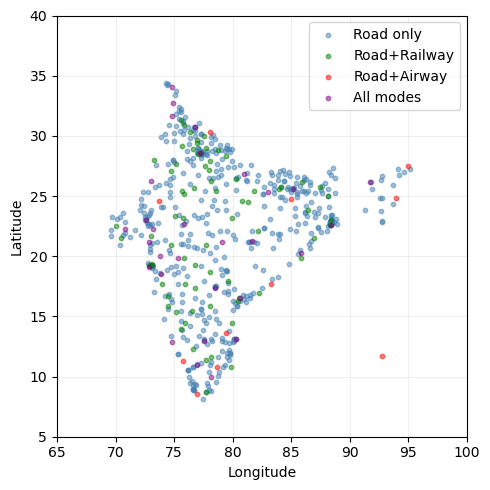

In [146]:
plot_cities(df, air_df, rail_df)

In [147]:
weights = {
    "fuel": 0,
    "carbon": 0,
    "time": 1,
}

In [148]:
transport_costs, cost_components, next_node = analyse_network(df, air_df, rail_df, weights)

Step 1/3: Calculating physical distance matrix...
Step 2/3: Building direct transport cost matrix...


Building transport cost matrix: 100%|█████████| 602/602 [00:38<00:00, 15.61it/s]


Step 3/3: Running Floyd-Warshall algorithm...


Running Floyd Warshall algorithm: 100%|███████| 602/602 [00:21<00:00, 28.19it/s]


In [149]:
a, fca = calc_network_cost(df, fc_cnd, transport_costs, cost_components)

In [166]:
generation_size = 50
reproduction_rate = 0.01
mutation_rate = 0.01
pop_size = np.unique(fca['fc'].values).size
num_generations = 2

In [161]:
generation = init_pop(pop_size = pop_size, count = generation_size)

In [270]:
def genetic_algorithm(generation_size: int,
                      reproduction_rate: float,
                      mutation_rate: float,
                      pop_size: int,
                      num_generations: int,
                      df: pd.DataFrame,
                      fc_df: pd.DataFrame):

    # Generation 0
    current_gen = init_pop(pop_size = pop_size, count = generation_size)

    for gen in range(num_generations):
        
        new_gen = np.zeros(current_gen.shape)

In [267]:
genetic_algorithm(generation_size = generation_size, 
                  reproduction_rate = reproduction_rate, 
                  mutation_rate = mutation_rate, 
                  pop_size = pop_size,
                  num_generations = num_generations,
                  df = df,
                  fc_df = fc_df)

array([25, 28, 24, 28, 19, 26, 27, 26, 25, 27, 37, 28, 27, 15, 21, 27, 18,
       28, 21, 27, 22, 23, 28])

In [216]:
np.mean(a)

11.46

In [268]:
a

array([32, 25, 23, 30, 19, 27, 25, 25, 21, 25, 22, 30, 27, 30, 21, 25, 23,
       26, 26, 28, 24, 23, 21])

In [269]:
np.zeros(a.shape)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0.])